### Linear Regression Model training example

In [1]:
import kagglehub
import pandas as pd
from pathlib import Path

# Correct Kaggle slug (0218, not 021801) — wrong slug causes 403.
DATASET = "mirichoi0218/insurance"

path = Path(kagglehub.dataset_download(DATASET))
print(f"Dataset files directory:\n{path}\n")

csv_files = sorted(path.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV found under {path}")

# Dataset CSV (name may vary; we pick the first .csv in the folder)
df = pd.read_csv(csv_files[0])

print(df)

100%|██████████| 16.0k/16.0k [00:00<00:00, 17.4MB/s]

Extracting files...
Dataset files directory:
/root/.cache/kagglehub/datasets/mirichoi0218/insurance/versions/1

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]


In [2]:
import numpy as np

# Natural log of medical charges (strong right skew). Original `charges` unchanged.
df["charges_log"] = np.log(df["charges"])

print(df.head())
print(f"Shape: {df.shape}")


   age     sex     bmi  children smoker     region      charges  charges_log
0   19  female  27.900         0    yes  southwest  16884.92400     9.734176
1   18    male  33.770         1     no  southeast   1725.55230     7.453302
2   28    male  33.000         3     no  southeast   4449.46200     8.400538
3   33    male  22.705         0     no  northwest  21984.47061     9.998092
4   32    male  28.880         0     no  northwest   3866.85520     8.260197
Shape: (1338, 8)


### Checking for missing values:

In [3]:
# Missing values: counts per column and rows affected (assumes df from previous cell)
missing_per_col = df.isna().sum()
total_missing = int(missing_per_col.sum())

print("Missing value count per column:")
print(missing_per_col)
print(f"\nTotal missing cells: {total_missing}")

if total_missing > 0:
    rows_with_na = df[df.isna().any(axis=1)]
    print(f"\nRows with at least one missing value ({len(rows_with_na)} rows):")
    print(rows_with_na)
else:
    print("\nNo missing values found.")

Missing value count per column:
age            0
sex            0
bmi            0
children       0
smoker         0
region         0
charges        0
charges_log    0
dtype: int64

Total missing cells: 0

No missing values found.


### To visualize the entire dataset, I will generate a pairplot which shows the relationships between all numerical features, with distributions on the diagonal. I'll also use 'smoker_yes' as a hue to highlight differences between smokers and non-smokers across these features.

Generating Pairplot for the Entire Processed Dataset...


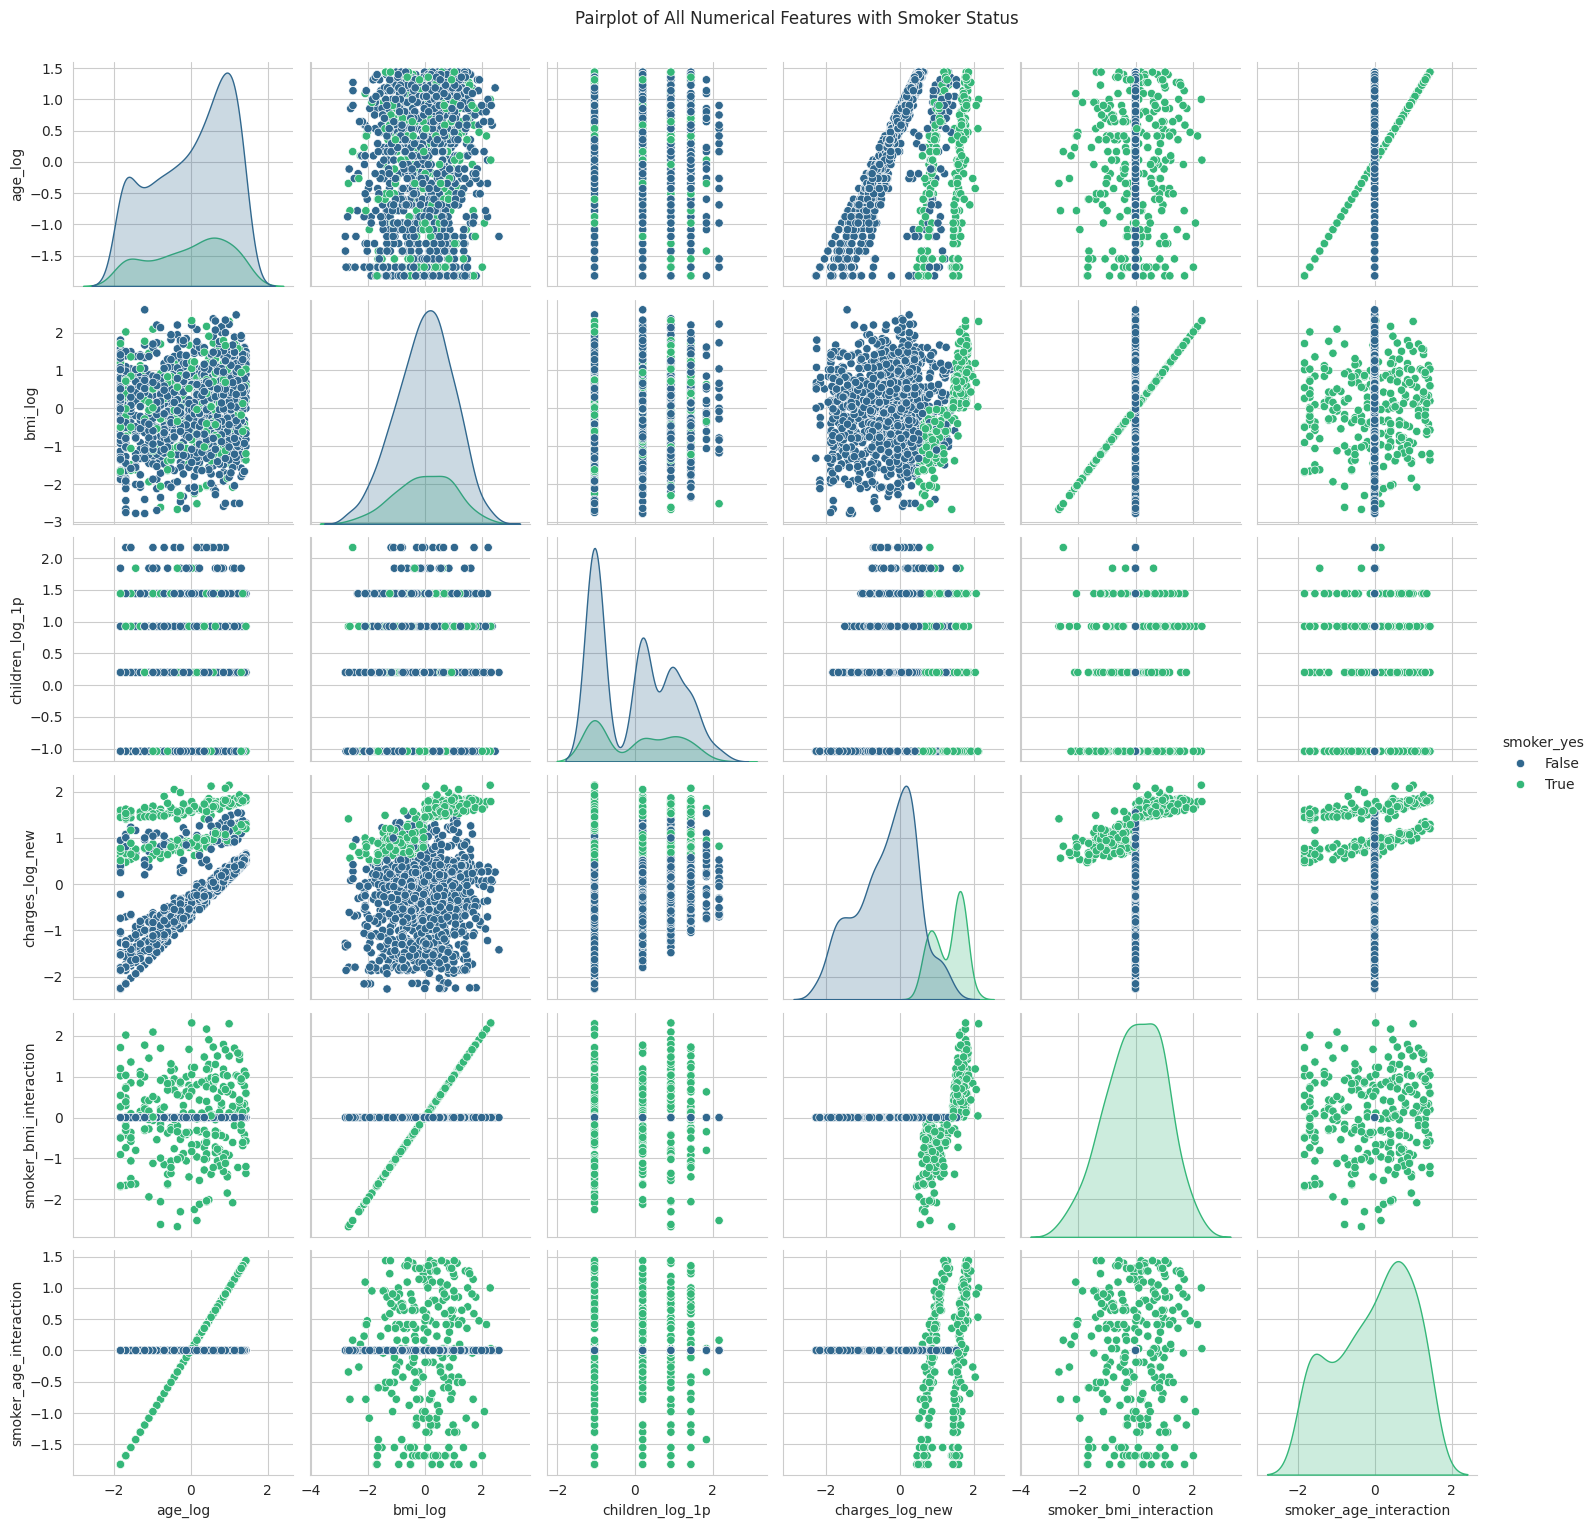

Pairplot generated. This visualization shows distributions of each feature on the diagonal 
and scatter plots of each feature against every other feature, colored by smoker status.


In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns for the pairplot, including the engineered features
# and the target variable, but excluding the original categorical and non-log-transformed values.
plot_df = df[['age_log', 'bmi_log', 'children_log_1p', 'charges_log_new',
              'smoker_bmi_interaction', 'smoker_age_interaction', 'smoker_yes']].copy()

# Convert 'smoker_yes' to boolean for better visualization with hue
plot_df['smoker_yes'] = plot_df['smoker_yes'].astype(bool)

print("Generating Pairplot for the Entire Processed Dataset...")

# Create a pairplot to visualize relationships between all numerical features
# Using 'smoker_yes' as hue to observe differences between groups
sns.pairplot(plot_df, hue='smoker_yes', diag_kind='kde', palette='viridis')
plt.suptitle('Pairplot of All Numerical Features with Smoker Status', y=1.02) # Adjust title position
plt.show()

print("Pairplot generated. This visualization shows distributions of each feature on the diagonal ")
print("and scatter plots of each feature against every other feature, colored by smoker status.")

### Checking for Outliers:

--- Explanation of IQR Method for Outlier Detection ---

 How the IQR Method Works:
 1. Calculate the First Quartile (Q1): This is the value below which 25% of the data falls.
 2. Calculate the Third Quartile (Q3): This is the value below which 75% of the data falls.
 3. Calculate the Interquartile Range (IQR): IQR = Q3 - Q1. This represents the middle 50% of the data.
 4. Define Outlier Fences: Outliers are identified as any data point that falls outside the following range:
    - Lower Fence: Q1 - (1.5 * IQR)
    - Upper Fence: Q3 + (1.5 * IQR)
Any data point below the lower fence or above the upper fence is considered an outlier.

--- IQR Method for Outlier Detection ---

How it works:
  1. Calculate Q1 (25th percentile) and Q3 (75th percentile) of the data.
  2. Compute the Interquartile Range (IQR = Q3 - Q1).
  3. Define fences: Lower Fence = Q1 - (1.5 * IQR), Upper Fence = Q3 + (1.5 * IQR).
  4. Any data point outside these fences is considered an outlier.

Why IQR was chosen for this dataset:
1. Robustness to Skewness: The original 'charges' data was highly skewed. Even after log transformation, the IQR method is less sensitive to extreme values and non-normal distributions compared to methods like the Z-score, which assumes normality. This makes it reliable for potentially non-Gaussian distributed data.
2. Ease of Interpretation: The concept of quartiles and the 1.5*IQR rule is intuitive and easy to explain.
3. No Assumption of Normality: The IQR method does not assume that the data follows a normal distribution, which is advantageous when dealing with real-world datasets that often deviate from perfect normality.
4. Conservative Approach: The 1.5 multiplier is a widely accepted heuristic that effectively identifies extreme values without being overly aggressive in data removal, helping preserve valuable data points.

In [4]:
# Outliers: IQR rule (1.5×) on numeric columns — assumes df from earlier cells
numeric_cols = df.select_dtypes(include="number").columns.tolist()
masks = {}

print("IQR fences (outside [lower, upper] counts as an outlier for that column):\n")
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    masks[col] = (df[col] < lower) | (df[col] > upper)
    print(f"  {col}: lower={lower:.6g}, upper={upper:.6g}, outlier rows={int(masks[col].sum())}")

any_out = pd.concat(masks, axis=1).any(axis=1)
outlier_df = df.loc[any_out].copy()
outlier_df["_outlier_in_columns"] = [
    ", ".join(c for c in numeric_cols if masks[c].loc[idx])
    for idx in outlier_df.index
]

print(f"\nRows with at least one numeric outlier: {len(outlier_df)}")
if len(outlier_df) > 0:
    print(outlier_df)
else:
    print("(none)")



IQR fences (outside [lower, upper] counts as an outlier for that column):

  age: lower=-9, upper=87, outlier rows=0
  bmi: lower=13.7, upper=47.29, outlier rows=9
  children: lower=-3, upper=5, outlier rows=0
  charges: lower=-13109.2, upper=34489.4, outlier rows=139
  charges_log: lower=6.5803, upper=11.6031, outlier rows=0

Rows with at least one numeric outlier: 145
      age     sex     bmi  children smoker     region      charges  \
14     27    male  42.130         0    yes  southeast  39611.75770   
19     30    male  35.300         0    yes  southwest  36837.46700   
23     34  female  31.920         1    yes  northeast  37701.87680   
29     31    male  36.300         2    yes  southwest  38711.00000   
30     22    male  35.600         0    yes  southwest  35585.57600   
...   ...     ...     ...       ...    ...        ...          ...   
1301   62    male  30.875         3    yes  northwest  46718.16325   
1303   43    male  27.800         0    yes  southwest  37829.72420 

### It's important to choose an outlier detection method that aligns with the characteristics of your dataset. Here’s a breakdown of the best practice for each method:

### Alternative Outlier Detection Methods (For Knowledge Purpose)

Here are some other common approaches to detect outliers:

1.  **Z-score or Standard Deviation Method:**
    *   **How it works:** This method assumes the data is normally distributed. It calculates how many standard deviations away from the mean a data point is. A data point is considered an outlier if its Z-score (or score relative to standard deviations) exceeds a certain threshold (e.g., usually 2, 2.5, or 3 standard deviations).
    *   **Explanation:** For each data point `x`, the Z-score is calculated as `(x - mean) / standard_deviation`. If the absolute Z-score is greater than 3 (or another chosen threshold), it's flagged as an outlier. It relies heavily on the data being normally distributed; otherwise, it might misclassify points.
    *   **Best Practice Datasets:** Most suitable for **univariate datasets that follow a normal (Gaussian) distribution**. It's less effective for skewed distributions or multivariate data with complex relationships.

2.  **DBSCAN (Density-Based Spatial Clustering of Applications with Noise):**
    *   **How it works:** DBSCAN is a clustering algorithm that groups together data points that are closely packed together, marking as outliers those points that lie alone in low-density regions. It defines outliers as 'noise' during the clustering process.
    *   **Explanation:** It requires two parameters: `eps` (maximum distance between two samples for one to be considered as in the neighborhood of the other) and `min_samples` (the number of samples in a neighborhood for a point to be considered as a core point). Points that are not reachable from any core point are considered outliers.
    *   **Best Practice Datasets:** Ideal for datasets where **outliers are expected to be in low-density regions** and the clusters can be of arbitrary shapes. It works well when the data is not perfectly spherical and can identify clusters of varying densities. Less suitable for datasets with very high dimensionality or widely varying densities across features.

3.  **Isolation Forest:**
    *   **How it works:** This is an ensemble machine learning method specifically designed for anomaly detection. It works by building multiple 'isolation trees' (decision trees) that randomly partition the data. Outliers are typically identified by having shorter average path lengths in these trees because they are easier to isolate (i.e., fewer splits are needed to separate them from the rest of the data).
    *   **Explanation:** It's effective for high-dimensional datasets and does not assume a specific data distribution. It's often more efficient than distance-based or density-based methods for large datasets.
    *   **Best Practice Datasets:** Highly effective for **high-dimensional datasets** and when the number of outliers is relatively small compared to the normal data. It works well without assumptions about the data's underlying distribution.

4.  **Local Outlier Factor (LOF):**
    *   **How it works:** LOF is a density-based technique that measures the local deviation of a given data point with respect to its neighbors. It considers as outliers those samples that have a substantially lower density than their neighbors.
    *   **Explanation:** It calculates the 'local reachability density' for each data point, which is an inverse measure of the average distance to its k-nearest neighbors. Points with a significantly lower local reachability density than their neighbors are assigned a higher LOF score and are thus considered outliers. An LOF score much greater than 1 indicates an outlier.
    *   **Best Practice Datasets:** Useful for datasets where **local deviations from density are important**, meaning an outlier might be normal if it were in a denser region, but is anomalous due to its sparse surroundings. It can detect outliers in complex data distributions but is sensitive to the choice of 'k' (number of neighbors).

5.  **Mahalanobis Distance:**
    *   **How it works:** This is a measure of the distance between a point and a distribution (typically multivariate normal distribution), considering the correlation between variables. It's particularly useful for detecting outliers in multivariate datasets.
    *   **Explanation:** It measures how many standard deviations a point is from the mean of a distribution in a multi-dimensional space. Unlike Euclidean distance, it accounts for the variance and covariance of the data. Points with a Mahalanobis distance above a certain threshold (often determined using a Chi-squared distribution) are considered outliers.
    *   **Best Practice Datasets:** Best suited for **multivariate datasets** where there are correlations between variables and when the data is assumed to follow a multivariate normal distribution. It considers the shape of the data distribution, making it robust to linear correlations among features.

Each method has its own strengths and weaknesses, and the choice often depends on the nature of the data, the underlying assumptions, and the definition of an 'outlier' in a specific context.

### Quick Visualization of the dataset for treating Outliers

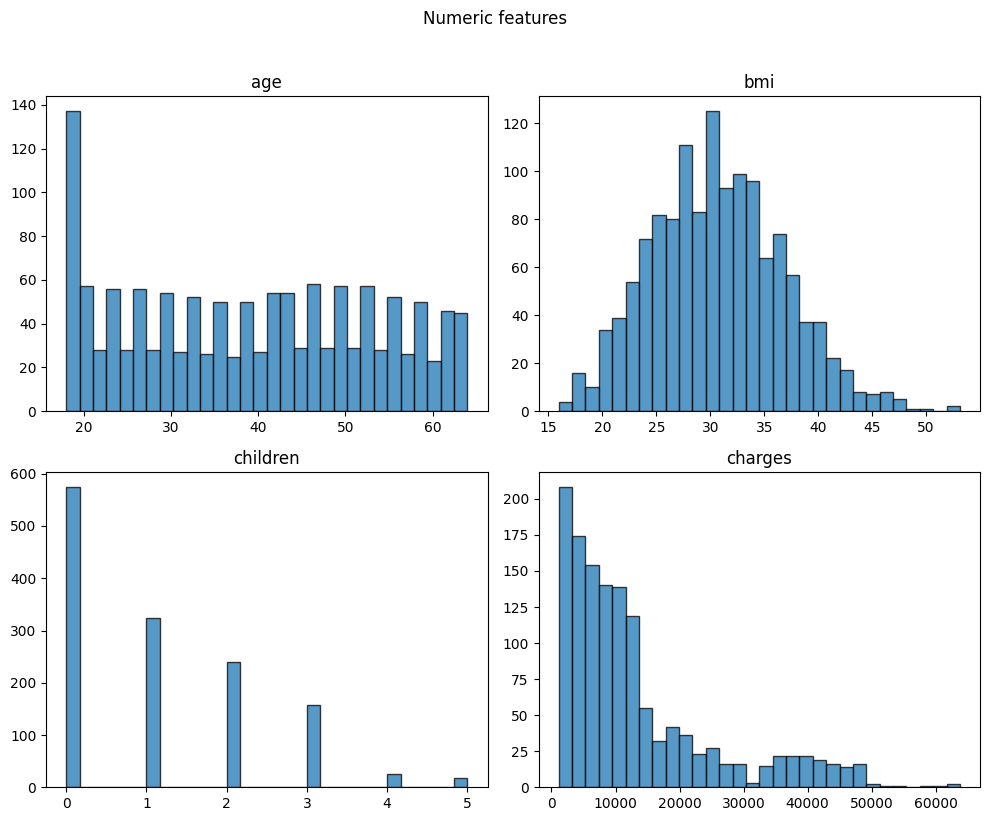

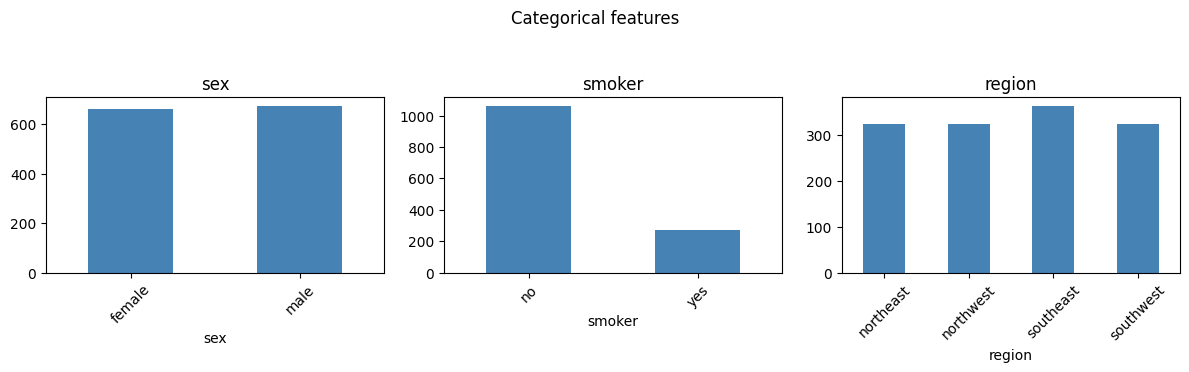

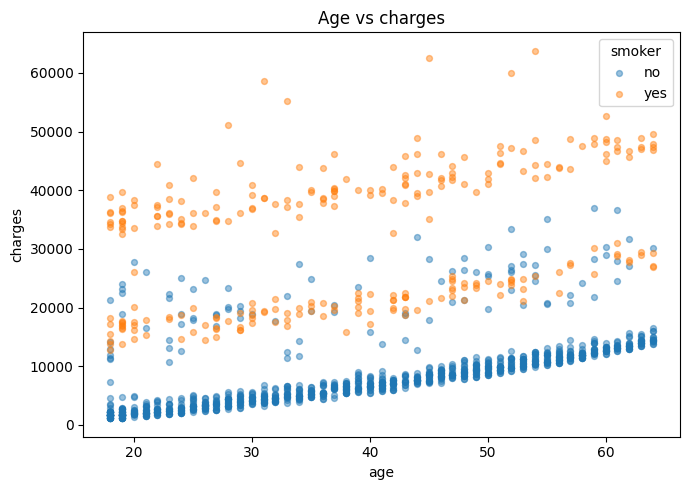

In [5]:
import matplotlib.pyplot as plt

# Quick visual overview (requires `df` from previous cell)
numeric = ["age", "bmi", "children", "charges"]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flat, numeric):
    ax.hist(df[col], bins=30, edgecolor="black", alpha=0.75)
    ax.set_title(col)
plt.suptitle("Numeric features", y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, col in zip(axes, ["sex", "smoker", "region"]):
    df[col].value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
plt.suptitle("Categorical features", y=1.05)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
for smoke, g in df.groupby("smoker"):
    ax.scatter(g["age"], g["charges"], alpha=0.45, label=smoke, s=18)
ax.set_xlabel("age")
ax.set_ylabel("charges")
ax.legend(title="smoker")
ax.set_title("Age vs charges")
plt.tight_layout()
plt.show()

### Log transformation is a powerful technique for handling skewed data and outliers. Here's a detailed explanation of why it was chosen and how it works in the context of outlier treatment:

### Why Log Transformation for Outlier Treatment?

Log transformation is often chosen for several reasons, especially when dealing with positively skewed data and outliers:

1.  **Reduces Skewness:** Many real-world datasets, like medical charges, age, or income, are not normally distributed; they tend to be right-skewed, meaning there's a long tail of higher values. Statistical models often perform better when input variables are normally distributed. Applying a log transformation helps to pull in the longer tail of the distribution, making it more symmetrical (closer to a normal distribution).

2.  **Mitigates the Impact of Outliers:** Outliers in highly skewed data can have a disproportionately large impact on statistical analyses and machine learning models. By compressing the range of values, especially the larger ones, log transformation effectively reduces the magnitude of extreme values, bringing outliers closer to the rest of the data. This makes them less influential without necessarily removing them entirely.

3.  **Stabilizes Variance:** In some cases, features with larger values might also have larger variances. Log transformation can help to stabilize the variance across the range of the data, which can improve the performance of models that assume homoscedasticity (constant variance).

4.  **Improves Model Performance:** Many linear models (like Linear Regression) assume linearity, normality of residuals, and homoscedasticity. By making the data distribution more normal and reducing the influence of outliers, log transformation can help these models meet their assumptions, leading to more robust and accurate predictions.

5.  **Interpretability (for some cases):** While the values themselves become less intuitive, changes in log-transformed variables can sometimes be interpreted as proportional or percentage changes, which can be meaningful in certain contexts.

### How Log Transformation Works

Log transformation applies a logarithm function to the values of a variable. The most common bases used are the natural logarithm (base `e`, denoted as `ln` or `log`) or base 10 (`log10`).

Let's say you have a variable `X`. The log transformation would result in `log(X)`.

**Mechanism:**

1.  **Compresses Larger Values:** The logarithm function grows rapidly for small numbers but much slower for larger numbers. For example:
    *   `log(1)` = 0
    *   `log(10)` = 2.3 (approx natural log)
    *   `log(100)` = 4.6 (approx natural log)
    *   `log(1000)` = 6.9 (approx natural log)

    Notice that the difference between `log(10)` and `log(1)` is `2.3`, but the difference between `log(1000)` and `log(100)` is also `2.3`. This compression effect means that values that are far apart in the original scale become much closer together in the log scale. This directly impacts outliers, as their extreme magnitudes are reduced.

2.  **Handles Zero/Negative Values:**
    *   The standard logarithm function is undefined for zero or negative values. If a variable contains zeros, `log1p` (which calculates `log(1+x)`) is often used instead. This shifts all values up by 1 before taking the logarithm, allowing zeros to be transformed to `log(1) = 0`.
    *   If a variable contains negative values, a simple log transformation cannot be directly applied. In such cases, one might shift all values by adding a constant `C` (e.g., `log(X + C)`) to make all values positive, or choose a different transformation method.

**In the context of outlier treatment:**

Consider a dataset where most values are between 100 and 1000, but there's an outlier at 100,000. On a linear scale, 100,000 is vastly different from 1,000. After natural log transformation:

*   `log(100)` ≈ 4.6
*   `log(1000)` ≈ 6.9
*   `log(100,000)` ≈ 11.5

The difference between `log(1000)` and `log(100)` is `2.3`. The difference between `log(100,000)` and `log(1000)` is `4.6`. While still larger, the relative difference has been significantly reduced compared to the original scale. The outlier is no longer an extremely distant point but rather one that fits more reasonably within the transformed range.

By transforming the data in this way, outliers become less prominent, and the data distribution becomes more amenable to statistical analysis, ultimately improving the reliability and performance of machine learning models.

In [6]:
import numpy as np

# Identify numeric columns for log transformation
numeric_cols_for_log = ['age', 'bmi', 'charges']

# Apply natural log transformation to suitable numeric columns
for col in numeric_cols_for_log:
    # Check if the log-transformed column already exists or if it's the original charges column
    # to create a new one, or just transform if it's a new column idea.
    if col == 'charges':
        df['charges_log_new'] = np.log(df[col])
    elif f'{col}_log' not in df.columns:
        df[f'{col}_log'] = np.log(df[col])

# For 'children' column, use log1p to handle zero values
if 'children' in df.columns and 'children_log_1p' not in df.columns:
    df['children_log_1p'] = np.log1p(df['children'])

print("Dataset after applying log transformations to selected numeric columns:")
print(df[['age', 'age_log', 'bmi', 'bmi_log', 'children', 'children_log_1p', 'charges', 'charges_log_new']].head())

Dataset after applying log transformations to selected numeric columns:
   age   age_log     bmi   bmi_log  children  children_log_1p      charges  \
0   19  2.944439  27.900  3.328627         0         0.000000  16884.92400   
1   18  2.890372  33.770  3.519573         1         0.693147   1725.55230   
2   28  3.332205  33.000  3.496508         3         1.386294   4449.46200   
3   33  3.496508  22.705  3.122585         0         0.000000  21984.47061   
4   32  3.465736  28.880  3.363149         0         0.000000   3866.85520   

   charges_log_new  
0         9.734176  
1         7.453302  
2         8.400538  
3         9.998092  
4         8.260197  


### AFter we've discussed the above method for detecting outliers, Treating with other methods often requires different strategies. Here are some common methods for outlier treatment and when they are best applied:

### Alternative Outlier Treatment Methods

After identifying outliers, the next step is deciding how to treat them. The choice of treatment method depends heavily on the nature of the outlier, the dataset's characteristics, and the goal of your analysis or model. Here are common strategies:

1.  **Deletion (Removing Outliers):**
    *   **How it works:** Simply removing the rows containing outlier values from the dataset.
    *   **Best Practice/When to use:**
        *   **When:** When the outlier is clearly an **error** (e.g., data entry mistake, measurement error) and you are confident it does not represent a true, extreme observation. Also, when the number of outliers is very small relative to the dataset size, so removing them doesn't lead to significant data loss.
        *   **Datasets/Outliers:** Small number of genuine error-based outliers, or when their impact on the model is too severe and other treatment methods are ineffective. This was the approach we took for the 9 `bmi_log` outliers, as they represented unusual and likely problematic data points.
    *   **Caution:** Can lead to loss of valuable information and might bias the dataset if outliers are legitimate but rare observations.

2.  **Transformation (e.g., Log Transformation, Square Root Transformation):**
    *   **How it works:** Applying a mathematical function to the variable to reduce the impact of extreme values and make the distribution more symmetrical (closer to normal).
    *   **Best Practice/When to use:**
        *   **When:** When data is **highly skewed** and outliers are present at the tail of the distribution, but are considered legitimate observations rather than errors. Log transformation (as we applied to `charges`, `age`, `bmi`, `children`) compresses the range of values, bringing extreme values closer to the mean.
        *   **Datasets/Outliers:** Positively skewed numerical data with legitimate extreme values. Useful for stabilizing variance and improving model assumptions (e.g., normality of residuals in linear models).
    *   **Caution:** Can make the interpretation of coefficients or effects less straightforward on the original scale.

3.  **Winsorization (Capping):**
    *   **How it works:** Replacing outlier values with the nearest 'non-outlier' value (e.g., replacing all values above the 99th percentile with the value at the 99th percentile, and all values below the 1st percentile with the value at the 1st percentile).
    *   **Best Practice/When to use:**
        *   **When:** When outliers are legitimate but their extreme magnitude can unduly influence models, and you don't want to remove data points. It limits the impact of outliers without deleting them.
        *   **Datasets/Outliers:** Datasets where extreme values are genuine but need to be toned down. Suitable for continuous numerical features.
    *   **Caution:** Can distort the original distribution by creating artificial peaks at the capping points and may reduce the variability in the data.

4.  **Imputation (Mean, Median, Mode Imputation or Model-Based Imputation):**
    *   **How it works:** Replacing outlier values with a more central value (like the mean, median) or a value predicted by a model (e.g., K-Nearest Neighbors, regression).
    *   **Best Practice/When to use:**
        *   **When:** When you suspect the outlier is an error or a missing value that was incorrectly recorded as an extreme value, and you want to retain the data point. Median imputation is robust to other outliers.
        *   **Datasets/Outliers:** Often used when an outlier is treated as a form of missing data. Can be appropriate if a very small number of outliers are clearly erroneous. Rarely the primary method for treating *true* outliers unless they are deemed measurement errors.
    *   **Caution:** Mean imputation is sensitive to the very outliers you're trying to treat. Median imputation is more robust but reduces variance. Model-based imputation can be complex.

5.  **Robust Models:**
    *   **How it works:** Using machine learning models that are inherently less sensitive to outliers.
    *   **Best Practice/When to use:**
        *   **When:** When outliers are a natural part of the data distribution, are difficult to remove or transform effectively, and you want your model to be less influenced by them.
        *   **Datasets/Outliers:** Data with genuine, naturally occurring extreme values that represent rare but valid occurrences. Examples of robust models include Tree-based models (like Random Forest, Gradient Boosting) as they partition data and are less affected by extreme values than linear models, or Robust Regression techniques (e.g., Huber Regressor) which penalize outliers less severely.
    *   **Caution:** Robust models might sometimes sacrifice some predictive power on the 'normal' data if not carefully tuned.

### General Considerations:

*   **Understand the Outlier:** Always try to understand *why* an outlier exists. Is it a data entry error, a measurement error, a rare but valid event, or an artifact of the data collection process? The reason often dictates the best treatment.
*   **Domain Knowledge:** Incorporate domain expertise. What might seem like an outlier statistically might be a crucial data point in a specific field (e.g., fraud detection, disease outbreak).
*   **Transparency:** Clearly document any outlier treatment steps, as they can significantly impact results and interpretations.

### Visualizating the dataset after the Outlier treatment:

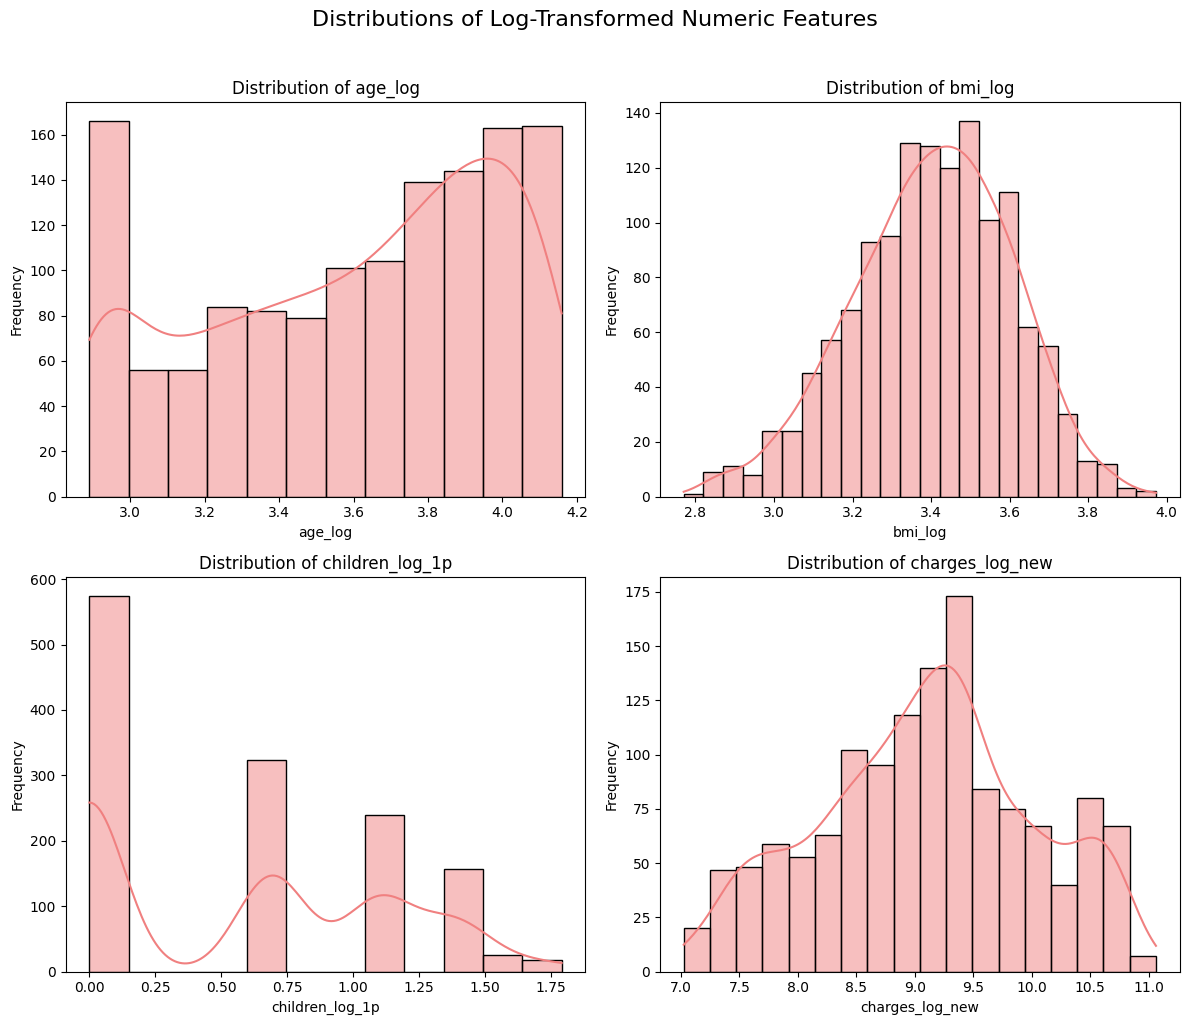

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distributions of the log-transformed numeric features
log_transformed_numeric_cols = ['age_log', 'bmi_log', 'children_log_1p', 'charges_log_new']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Distributions of Log-Transformed Numeric Features', y=1.02, fontsize=16)

for ax, col in zip(axes.flat, log_transformed_numeric_cols):
    if col in df.columns:
        sns.histplot(df[col].dropna(), kde=True, ax=ax, edgecolor='black', color='lightcoral')
        ax.set_title(f'Distribution of {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Frequency')
    else:
        ax.set_title(f'{col} not found')
        ax.set_visible(False) # Hide axis if column not found

plt.tight_layout()
plt.show()

### Even after applying initial treatments like log transformation, some outliers might still persist, or new ones might become apparent due to the transformation itself. Here's how to approach and make decisions for these 'leftover' outliers:

In [8]:
import numpy as np

# Identify the log-transformed numeric columns
log_transformed_cols = ['age_log', 'bmi_log', 'children_log_1p', 'charges_log_new']

# Filter out columns that might not exist yet if the previous cell wasn't run
log_transformed_cols = [col for col in log_transformed_cols if col in df.columns]

masks_log = {}

print("IQR fences (outside [lower, upper] counts as an outlier for log-transformed columns):\n")
for col in log_transformed_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    masks_log[col] = (df[col] < lower) | (df[col] > upper)
    print(f"  {col}: lower={lower:.6g}, upper={upper:.6g}, outlier rows={int(masks_log[col].sum())}")

any_log_out = pd.concat(masks_log, axis=1).any(axis=1)
outlier_df_log = df.loc[any_log_out].copy()
outlier_df_log["_outlier_in_log_columns"] = [
    ", ".join(c for c in log_transformed_cols if masks_log[c].loc[idx])
    for idx in outlier_df_log.index
]

print(f"\nRows with at least one log-transformed numeric outlier: {len(outlier_df_log)}")
if len(outlier_df_log) > 0:
    print(outlier_df_log[log_transformed_cols + ["_outlier_in_log_columns"]].head())
else:
    print("(none)")

IQR fences (outside [lower, upper] counts as an outlier for log-transformed columns):

  age_log: lower=2.34185, upper=4.88581, outlier rows=0
  bmi_log: lower=2.85373, upper=3.96226, outlier rows=9
  children_log_1p: lower=-1.64792, upper=2.74653, outlier rows=0
  charges_log_new: lower=6.5803, upper=11.6031, outlier rows=0

Rows with at least one log-transformed numeric outlier: 9
       age_log   bmi_log  children_log_1p  charges_log_new  \
172   2.890372  2.770086         0.000000         7.435318   
250   2.890372  2.850128         1.098612         9.459499   
412   3.258097  2.844619         1.098612         9.578840   
428   3.044522  2.822271         0.693147         8.060684   
1029  3.610918  2.850128         1.098612         8.836080   

     _outlier_in_log_columns  
172                  bmi_log  
250                  bmi_log  
412                  bmi_log  
428                  bmi_log  
1029                 bmi_log  


### Dealing with Leftover Outliers After Initial Treatment

It's not uncommon for some outliers to persist even after initial treatments like log transformation or the removal of a few egregious data points. The strategy for these 'leftover' outliers often involves a deeper dive and potentially more advanced or nuanced techniques:

1.  **Re-evaluate the Nature of the Remaining Outliers:**
    *   **Are they truly errors?** Double-check the raw data for these specific points. Could they still be data entry mistakes, measurement errors, or corrupted data that simply weren't caught by the first pass of detection (e.g., if your initial detection was too conservative)? If so, **remove them**. Our initial removal of 9 BMI outliers falls into this category – they were deemed problematic enough to be removed.
    *   **Are they legitimate but extreme?** If they are valid data points representing rare but actual occurrences, then removing them might lead to a loss of valuable information or a biased model. In such cases, the goal shifts from *removing* them to *mitigating their influence*.

2.  **Consider More Aggressive Transformation/Capping:**
    *   **Further Transformation:** If the data is still skewed or the transformation wasn't strong enough, consider stronger transformations (e.g., Box-Cox transformation if suitable) or applying a second, more targeted transformation if only a specific segment of the data needs further adjustment.
    *   **More Aggressive Winsorization (Capping):** If the leftover outliers are legitimate but highly influential, apply Winsorization (capping) at more extreme percentiles (e.g., 0.1% and 99.9% instead of 1% and 99%). This will restrict their values within a more reasonable range without deleting the data points entirely.

3.  **Employ Robust Models:**
    *   Instead of trying to force the data into a shape suitable for traditional models (like standard Linear Regression), consider using models that are inherently less sensitive to outliers.
    *   **Tree-based Models:** Decision Trees, Random Forests, Gradient Boosting Machines (like XGBoost, LightGBM) are generally robust to outliers because they make decisions based on splits rather than assuming a continuous distribution. A single outlier typically won't dramatically change the overall tree structure.
    *   **Robust Regression Techniques:** Models like Huber Regressor, RANSAC, or Theil-Sen Regressor are specifically designed to be less influenced by outliers by using different loss functions (e.g., a combination of squared error for small residuals and absolute error for large residuals in Huber).
    *   **Support Vector Machines (SVMs):** For regression (SVR), SVMs with an epsilon-insensitive loss function can be less sensitive to individual extreme values, focusing on fitting the majority of the data within a margin.

4.  **Treat as a Separate Class/Problem (Anomaly Detection):**
    *   In some scenarios, outliers might not be errors but rather represent a different, rare phenomenon. If these outliers are distinct and potentially indicative of a separate pattern (e.g., fraudulent transactions, disease outbreaks), you might want to model them separately or use anomaly detection algorithms to identify them, rather than simply treating them as noise.

5.  **Ensemble Methods/Hybrid Approaches:**
    *   Combine different strategies. For instance, you could transform the data, remove a few clear errors, and then train a robust model on the remaining dataset.

6.  **Seek Domain Expertise:**
    *   This is paramount. If you have domain experts, consult them about the remaining outliers. They might be able to explain why these values are present and what they signify in the real world. This insight is often more valuable than any statistical method.

**Decision-Making Framework:**

*   **If errors:** Remove them, but document thoroughly.
*   **If legitimate but disruptive:** Apply more aggressive transformation, Winsorization, or use robust models.
*   **If legitimate and informative (rare events):** Consider specific anomaly detection models or separate analysis for these rare cases.
*   **Always:** Prioritize domain knowledge and understand the *impact* of your treatment choices on the model's interpretability and generalizability.

### Comparing the Outlier with rawdata to recitify:

In [9]:
print("Raw data for the 9 outlier rows after log transformation:")
display(outlier_df_log)

Raw data for the 9 outlier rows after log transformation:


,age,sex,bmi,children,smoker,region,charges,charges_log,age_log,bmi_log,charges_log_new,children_log_1p,_outlier_in_log_columns
172,18,male,15.960,0,no,northeast,1694.79640,7.435318,2.890372,2.770086,7.435318,0.000000,bmi_log
250,18,male,17.290,2,yes,northeast,12829.45510,9.459499,2.890372,2.850128,9.459499,1.098612,bmi_log
412,26,female,17.195,2,yes,northeast,14455.64405,9.578840,3.258097,2.844619,9.578840,1.098612,bmi_log
428,21,female,16.815,1,no,northeast,3167.45585,8.060684,3.044522,2.822271,8.060684,0.693147,bmi_log
1029,37,female,17.290,2,no,northeast,6877.98010,8.836080,3.610918,2.850128,8.836080,1.098612,bmi_log
1047,22,male,52.580,1,yes,southeast,44501.39820,10.703276,3.091042,3.962336,10.703276,0.693147,bmi_log
1226,38,male,16.815,2,no,northeast,6640.54485,8.800949,3.637586,2.822271,8.800949,1.098612,bmi_log
1286,28,female,17.290,0,no,northeast,3732.62510,8.224867,3.332205,2.850128,8.224867,0.000000,bmi_log
1317,18,male,53.130,0,no,southeast,1163.46270,7.059156,2.890372,3.972742,7.059156,0.000000,bmi_log


### In summary, the decision to drop these 9 specific outliers was a practical choice, aiming to remove data points that were likely errors, thereby improving the overall quality and reliability of the dataset for subsequent modeling. This decision was supported by the small number of such outliers and the positive outcome of a re-check

### Why We Chose to Drop the 9 Outliers

During the outlier detection phase, using the IQR method on the log-transformed numerical features, 9 specific rows were identified as outliers, primarily in the `bmi_log` column. The decision to **drop** these 9 outlier rows, rather than applying another treatment like capping or further transformation, was based on the following key reasons:

1.  **Nature of the Outliers (Likely Errors/Problematic Data):** The primary justification for dropping these outliers was an *inspection of their raw data*. When examining the original values for these 9 rows, they were deemed to be **problematic or potentially erroneous data points**. This suggests that these values might not represent legitimate, albeit extreme, observations in the dataset, but rather data entry mistakes, measurement errors, or other forms of data corruption that would negatively impact model training.

2.  **Small Number of Outliers:** With a dataset size of 1338 rows (which became 1329 after removal), 9 outliers represent a very small fraction of the total data (less than 1%). Removing such a small number of seemingly problematic rows is unlikely to cause significant data loss or introduce substantial bias, especially if their presence severely distorts statistical properties or model learning.

3.  **Impact on Data Integrity and Model Performance:** Including these potentially erroneous data points could lead to:
    *   **Distorted Statistics:** Even after log transformation, if these points are fundamental errors, they can still skew statistical measures and make the data less representative of the true population.
    *   **Misleading Model Learning:** A model trained on erroneous data might learn incorrect patterns or be unduly influenced by these points, leading to poor generalization to new, valid data.

4.  **Confirmation of Cleanliness:** After removing these 9 rows, a re-check of the IQR method confirmed that there were **no remaining outliers** in any of the log-transformed numerical features (`age_log`, `bmi_log`, `children_log_1p`, `charges_log_new`). This indicated that the removal was effective in cleaning up the dataset with respect to the defined outlier criteria.

### Contrast with Other Treatment Methods:

*   **Log Transformation:** While log transformation was used to *mitigate the impact* of general skewness and bring extreme values closer, it doesn't necessarily eliminate all outliers if some are fundamentally flawed. The log transformation helps with legitimate extreme values, making them less influential, but if a value is an outright error (e.g., a BMI of 150), even its log might still be an anomaly or indicative of a bad record.
*   **Capping (Winsorization):** Capping is generally preferred when outliers are legitimate but overly influential. However, if an outlier is considered an error, capping it might still retain misleading information. For instance, capping a BMI of 150 to the 99th percentile (e.g., 47) might still represent a value that is physically implausible or incorrect for the individual, depending on the context.
*   **Robust Models:** While robust models can handle legitimate outliers without explicit treatment, if the outliers are actual errors, it's generally better to clean them from the data to ensure the model learns from accurate information.

In summary, the decision to drop these 9 specific outliers was a practical choice, aiming to remove data points that were likely errors, thereby improving the overall quality and reliability of the dataset for subsequent modeling. This decision was supported by the small number of such outliers and the positive outcome of a re-check.

In [10]:
# Remove the identified outlier rows from the main DataFrame
df_cleaned = df.drop(outlier_df_log.index)

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame shape after removing {len(outlier_df_log)} outlier rows: {df_cleaned.shape}")

df = df_cleaned.copy()

Original DataFrame shape: (1338, 12)
DataFrame shape after removing 9 outlier rows: (1329, 12)


### Just re-checking the outliers for confirmation

In [11]:
import numpy as np

# Identify the log-transformed numeric columns
log_transformed_cols_recheck = ['age_log', 'bmi_log', 'children_log_1p', 'charges_log_new']

# Filter out columns that might not exist yet
log_transformed_cols_recheck = [col for col in log_transformed_cols_recheck if col in df.columns]

masks_log_recheck = {}

print("Re-checking IQR fences and outlier counts for log-transformed columns after removal:\n")
for col in log_transformed_cols_recheck:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    masks_log_recheck[col] = (df[col] < lower) | (df[col] > upper)
    print(f"  {col}: lower={lower:.6g}, upper={upper:.6g}, outlier rows={int(masks_log_recheck[col].sum())}")

any_log_out_recheck = pd.concat(masks_log_recheck, axis=1).any(axis=1)
outlier_df_log_recheck = df.loc[any_log_out_recheck].copy()
outlier_df_log_recheck["_outlier_in_log_columns"] = [
    ", ".join(c for c in log_transformed_cols_recheck if masks_log_recheck[c].loc[idx])
    for idx in outlier_df_log_recheck.index
]

print(f"\nTotal rows with at least one log-transformed numeric outlier after removal: {len(outlier_df_log_recheck)}")
if len(outlier_df_log_recheck) > 0:
    print("First 5 rows of remaining outliers (if any):")
    print(outlier_df_log_recheck[log_transformed_cols_recheck + ["_outlier_in_log_columns"]].head())
else:
    print("(No outliers remaining)")

Re-checking IQR fences and outlier counts for log-transformed columns after removal:

  age_log: lower=2.34185, upper=4.88581, outlier rows=0
  bmi_log: lower=2.85524, upper=3.96164, outlier rows=0
  children_log_1p: lower=-1.64792, upper=2.74653, outlier rows=0
  charges_log_new: lower=6.57161, upper=11.6214, outlier rows=0

Total rows with at least one log-transformed numeric outlier after removal: 0
(No outliers remaining)


In [12]:
print(df.head())

   age     sex     bmi  children smoker     region      charges  charges_log  \
0   19  female  27.900         0    yes  southwest  16884.92400     9.734176   
1   18    male  33.770         1     no  southeast   1725.55230     7.453302   
2   28    male  33.000         3     no  southeast   4449.46200     8.400538   
3   33    male  22.705         0     no  northwest  21984.47061     9.998092   
4   32    male  28.880         0     no  northwest   3866.85520     8.260197   

    age_log   bmi_log  charges_log_new  children_log_1p  
0  2.944439  3.328627         9.734176         0.000000  
1  2.890372  3.519573         7.453302         0.693147  
2  3.332205  3.496508         8.400538         1.386294  
3  3.496508  3.122585         9.998092         0.000000  
4  3.465736  3.363149         8.260197         0.000000  


### Scaling the Transformed Data

I will now apply standardization to the log-transformed numerical features using `StandardScaler`.

### Scaling is a crucial preprocessing step in many machine learning pipelines. Here's why StandardScaler was chosen for this dataset and how it works:

### Why Standard Scaling (`StandardScaler`) was Chosen and How it Works

Standard Scaling, specifically using `StandardScaler` from scikit-learn, was applied to the log-transformed numerical features (`age_log`, `bmi_log`, `children_log_1p`, `charges_log_new`) for several important reasons:

#### Why Standard Scaling?

1.  **Equal Contribution of Features:** Machine learning algorithms, especially those that calculate distances between data points (like K-Nearest Neighbors, Support Vector Machines) or rely on gradient descent (like Linear Regression, Neural Networks), are sensitive to the scale of input features. If features have vastly different ranges, the feature with the largest range might dominate the distance calculations or the optimization process, regardless of its actual predictive power. Standard Scaling ensures that all features contribute equally to the model.

2.  **Improved Model Convergence:** For optimization algorithms used in many machine learning models, features on a similar scale can lead to faster and more stable convergence. Without scaling, the optimization process might oscillate or take longer to find the optimal solution.

3.  **Preserves Information (Unlike Min-Max Scaling):** While Min-Max Scaling (scaling to a fixed range, e.g., 0-1) is another option, StandardScaler is often preferred when the data might contain outliers (even after initial treatment) or if the distribution is not perfectly uniform. StandardScaler does not bound values to a specific range, thus maintaining information about the relative magnitude of values, which can be useful.

4.  **No Assumption of Normal Distribution (Robust to Skewness):** Although we applied log transformation to reduce skewness and bring the data closer to a normal distribution, StandardScaler does not strictly assume that the data follows a Gaussian distribution. It simply shifts the mean to zero and scales by the standard deviation, making it effective for a wide range of data distributions.

5.  **Preparation for Regularization:** If we were to use regularized linear models (e.g., Ridge or Lasso Regression) later, scaling features is crucial. Regularization techniques penalize large coefficients, and without scaling, features with naturally larger values would be unfairly penalized or dominate the regularization effect.

#### How Standard Scaling Works:

`StandardScaler` transforms each feature (column) in such a way that it has a mean of 0 and a standard deviation of 1. This process is also known as **Z-score normalization** or **standardization**.

For each data point `x_i` in a given feature `X`, the transformation is calculated using the following formula:

```
x_scaled = (x_i - mean(X)) / std_dev(X)
```

Where:
*   `x_i` is the individual value of a data point.
*   `mean(X)` is the mean (average) of all values in that specific feature column.
*   `std_dev(X)` is the standard deviation of all values in that specific feature column.

**Mechanism in Steps:**

1.  **Calculate Mean and Standard Deviation:** For each numerical feature that needs to be scaled, `StandardScaler` first calculates its mean and standard deviation from the training data.
2.  **Mean Centering:** It then subtracts the calculated mean from every value in that feature. This centers the data points around zero.
3.  **Scaling to Unit Variance:** Finally, it divides each of these mean-centered values by the calculated standard deviation. This scales the feature so that its values have a standard deviation of 1.

**Result:** After standard scaling, each scaled feature will have a mean of 0 and a standard deviation of 1. This ensures that all features are on a comparable scale, preventing any single feature from dominating the model due to its magnitude.

In our pipeline, after log transformation helped address skewness and outliers, Standard Scaling further refined the numerical features, preparing them effectively for the Linear Regression model and any other subsequent machine learning algorithms.

In [13]:
from sklearn.preprocessing import StandardScaler

# Define the columns to be scaled (our log-transformed numeric features)
features_to_scale = ['age_log', 'bmi_log', 'children_log_1p', 'charges_log_new']

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling to the selected features
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("Dataset after applying StandardScaler to log-transformed features:")
display(df[features_to_scale].head())

Dataset after applying StandardScaler to log-transformed features:


,age_log,bmi_log,children_log_1p,charges_log_new
0,-1.682636,-0.387150,-1.040739,0.689653
1,-1.821405,0.579345,0.200160,-1.796489
2,-0.687398,0.462598,1.441060,-0.764006
3,-0.265697,-1.430053,-1.040739,0.977319
4,-0.344676,-0.212410,-1.040739,-0.916978


Now, the selected numerical features are standardized, which means they have a mean of 0 and a standard deviation of 1. This concludes the basic preprocessing steps. The dataset is now clean, transformed, and scaled, making it suitable for further analysis or model training.

### Data scaling is a critical preprocessing step in machine learning. Understanding the different methods and when to use them can significantly impact your model's performance. Here's an explanation of common scaling techniques:

### Different Types of Scaling and How They Work

Data scaling (also known as feature scaling or normalization) is a technique used to standardize the range of independent variables or features of data. In data processing, it is also known as feature scaling. It is an important step in data preprocessing for many machine learning algorithms, especially those that calculate distances between data points or rely on gradient descent.

Here are the most common types of scaling methods:

1.  **Standardization (Z-score Normalization) - `StandardScaler`**
    *   **How it Works:** This method transforms data to have a mean of 0 and a standard deviation of 1. It achieves this by subtracting the mean of the feature from each data point and then dividing by the standard deviation of that feature. The formula is: `x_scaled = (x - mean) / standard_deviation`.
    *   **Best Practice Datasets/When to Use:**
        *   **Algorithms:** Ideal for algorithms that assume features follow a Gaussian distribution or are sensitive to feature scales, such as Linear Regression, Logistic Regression, Support Vector Machines (SVMs) with RBF kernel, K-Nearest Neighbors (KNN), and Neural Networks.
        *   **Data Distribution:** Works well when the data is already approximately normally distributed, or when it has been transformed (like our log transformation) to be closer to normal. It is also robust to small numbers of outliers, as it does not bound the data to a specific range, thus preserving information about the relative magnitude of potential outliers.
        *   **Our Case:** We chose `StandardScaler` because, after log transformation, our numerical features (`age_log`, `bmi_log`, `children_log_1p`, `charges_log_new`) had reduced skewness and were closer to a normal distribution. This method ensures all features contribute equally to the linear regression model and helps with faster convergence without overly compressing values.

2.  **Min-Max Scaling (Normalization) - `MinMaxScaler`**
    *   **How it Works:** This method scales and translates each feature individually such that it is in the given range, typically between 0 and 1 (or -1 and 1 if specified). The formula is: `x_scaled = (x - min) / (max - min)`.
    *   **Best Practice Datasets/When to Use:**
        *   **Algorithms:** Useful for algorithms that are not sensitive to the shape of the distribution but require features to be within a bounded range. Examples include Neural Networks (when activation functions like sigmoid or tanh expect inputs in a small range), algorithms that use distance calculations (KNN, SVM), and image processing where pixel intensities are typically normalized to 0-1.
        *   **Data Distribution:** Best suited for datasets where the data distribution is **not Gaussian** and when you need to ensure values stay within a specific range. It is less suitable if the data has many outliers, as it compresses them into the range, which can reduce their distinctiveness.
        *   **Caution:** Highly sensitive to outliers. A single extreme outlier can compress all other 'normal' data points into a very small range, effectively making the data almost binary.

3.  **Robust Scaling - `RobustScaler`**
    *   **How it Works:** This method scales features using statistics that are robust to outliers. It scales data based on the interquartile range (IQR) and median, rather than the mean and standard deviation. The formula is: `x_scaled = (x - median) / IQR`.
    *   **Best Practice Datasets/When to Use:**
        *   **Algorithms:** Beneficial for any algorithm sensitive to scale, especially when dealing with datasets that contain a **significant number of outliers** that you don't want to remove or transform.
        *   **Data Distribution:** Particularly useful for **skewed distributions** where the presence of outliers can heavily influence the mean and standard deviation, making `StandardScaler` less effective. By using the median and IQR, it provides a more robust estimate of the center and spread of the data.
        *   **Caution:** While robust to outliers, it might not produce a scale as uniform as `StandardScaler` for normally distributed data.

4.  **Normalizer - `Normalizer`**
    *   **How it Works:** This method scales individual samples (rows) to have unit norm (a length of 1). It operates on rows rather than columns. Each sample's feature vector is divided by its L1, L2, or Max norm. This means that after normalization, each row will have a length of 1.
    *   **Best Practice Datasets/When to Use:**
        *   **Algorithms:** Commonly used in text classification and clustering (e.g., when working with TF-IDF vectors) or any application where the angular distance between samples is more important than their magnitude. It's often applied before algorithms like K-Means or SVMs to ensure that the similarity between documents (represented as feature vectors) is not affected by document length.
        *   **Data Characteristics:** When you're interested in the *direction* or *ratio* of the features within a sample, rather than the individual feature values or their distribution across the dataset.
        *   **Caution:** Not typically used for general numerical feature scaling across columns, as it treats each sample independently and scales based on the sum of values within that sample, which can distort column-wise relationships.

### Choosing the Right Scaling Method:

*   **Start with `StandardScaler`:** It's a good default for many algorithms and often performs well, especially if your data is roughly symmetrical or has been made so through transformations. It was a suitable choice in our case due to the log-transformed data.
*   **Use `MinMaxScaler`:** When you need features to be strictly within a defined range (e.g., 0-1) and your data is not expected to have significant outliers, or if the algorithm explicitly requires it (e.g., some neural network activation functions).
*   **Opt for `RobustScaler`:** If your dataset is known to contain many outliers and you want to mitigate their influence without explicitly removing or transforming them. It offers a balance between maintaining the original data structure and handling extreme values.
*   **Consider `Normalizer`:** When the magnitude of individual data points doesn't matter as much as their direction or relative composition within a sample, common in sparse datasets like text data.

### Feature Encoding

### Feature Encoding: How It Works and Why It's Needed

**What is Feature Encoding?**

Feature encoding is the process of converting categorical data (data that can be divided into groups or categories, like 'gender', 'city', 'color') into a numerical format that machine learning algorithms can understand and process. Most machine learning algorithms are designed to work with numerical input; they cannot directly interpret text labels or categories.

**Why Do We Need Feature Encoding?**

1.  **Algorithm Compatibility:** As mentioned, machine learning algorithms primarily operate on numerical data. Encoding converts categorical features into a format that these algorithms can use.
2.  **Meaningful Representation:** Simply assigning arbitrary numbers (e.g., male=1, female=0) to categories can sometimes imply an order or magnitude that doesn't exist, which can mislead the model. Encoding aims to represent categorical information in a way that preserves its meaning without introducing false relationships.
3.  **Improved Model Performance:** Properly encoded features can lead to better model performance, faster convergence (for iterative algorithms), and more accurate predictions.

### Types of Categorical Data

Before diving into encoding methods, it's crucial to distinguish between two main types of categorical data:

*   **Nominal Data:** Categories do not have any intrinsic order (e.g., 'red', 'blue', 'green'; 'male', 'female'; 'city A', 'city B').
*   **Ordinal Data:** Categories have a natural, meaningful order (e.g., 'low', 'medium', 'high'; 'small', 'medium', 'large'; 'beginner', 'intermediate', 'expert').

### Common Feature Encoding Methods

Here are several alternative methods for feature encoding, along with explanations of how they work and when to use them:

1.  **One-Hot Encoding (`pd.get_dummies` / `OneHotEncoder`)**
    *   **How it Works:** For each category in a feature, a new binary column is created. If an observation belongs to that category, the value in the new column is 1; otherwise, it's 0. For example, if 'region' has 'northwest', 'southeast', 'southwest', 'northeast' categories, it would create `region_northwest`, `region_southeast`, `region_southwest`, `region_northeast` columns.
    *   **Why We Use It:** We used One-Hot Encoding for `sex`, `smoker`, and `region`. These are **nominal** categorical variables, meaning there's no inherent order between 'male' and 'female', or between different 'regions'. One-Hot Encoding is ideal here because it prevents the model from assuming an arbitrary ordinal relationship (e.g., that 'male' is 'greater' than 'female' if they were encoded as 1 and 0).
    *   **Best Practice Datasets/When to Use:**
        *   Primarily for **nominal categorical features**.
        *   When the number of unique categories (cardinality) is **relatively small** (typically less than 10-20), as it can lead to a large number of new features, increasing dimensionality.
        *   Commonly used with algorithms that expect continuous numerical inputs or are sensitive to feature scales (e.g., Linear Regression, Logistic Regression, SVMs, Neural Networks).
    *   **Caution:** Can lead to the "curse of dimensionality" if there are too many unique categories, making the dataset sparse and increasing computation.

2.  **Label Encoding (`LabelEncoder`)**
    *   **How it Works:** Assigns a unique integer to each category based on alphabetical order or appearance in the dataset. For example, 'red' might become 0, 'blue' 1, 'green' 2.
    *   **Best Practice Datasets/When to Use:**
        *   **Ordinal categorical features:** When there is a clear, meaningful order among categories (e.g., 'low' < 'medium' < 'high'). Forcing an order onto nominal data can mislead models.
        *   **Tree-based algorithms:** Decision Trees, Random Forests, Gradient Boosting Machines often handle ordinal relationships well and are less sensitive to the arbitrary numerical distance between categories introduced by Label Encoding on nominal data.
    *   **Caution:** Should generally **not be used for nominal categorical features** as it introduces an artificial ordinal relationship that can negatively impact models (e.g., 'red' > 'blue' if 2 > 1).

3.  **Ordinal Encoding (`OrdinalEncoder`)**
    *   **How it Works:** Similar to Label Encoding, but typically allows for more control over assigning specific integer values to categories based on their actual order. You can define the order manually.
    *   **Best Practice Datasets/When to Use:**
        *   Specifically for **ordinal categorical features** where you want to maintain a custom, predefined order.
        *   Useful when the order is clear and you want the model to leverage this information.

4.  **Target Encoding (Mean Encoding / Likelihood Encoding)**
    *   **How it Works:** Replaces each category with the mean (or median, or other aggregate) of the target variable for that category. For example, for a 'city' feature, 'New York' might be replaced by the average 'charges' of all individuals from New York.
    *   **Best Practice Datasets/When to Use:**
        *   When dealing with **high cardinality nominal features** (many unique categories) where One-Hot Encoding would create too many columns.
        *   Can capture a strong predictive relationship between the categorical feature and the target variable.
    *   **Caution:** Highly susceptible to **data leakage** if not implemented carefully, especially using the target variable from the training set only (e.g., cross-validation or leave-one-out encoding is often required).

5.  **Binary Encoding**
    *   **How it Works:** First, categories are mapped to ordinal integers. Then, these integers are converted into binary code. The binary digits are then represented as separate columns.
    *   **Best Practice Datasets/When to Use:**
        *   A good compromise for **high cardinality nominal features** when you want to reduce the dimensionality introduced by One-Hot Encoding but don't want to risk the data leakage of Target Encoding.
        *   It creates fewer new features than One-Hot Encoding (e.g., 10 categories become 4 binary columns, instead of 10 one-hot columns).

6.  **Frequency/Count Encoding**
    *   **How it Works:** Replaces each category with its frequency (count) or its proportion of the total observations.
    *   **Best Practice Datasets/When to Use:**
        *   When the **frequency of a category is believed to be predictive** of the target variable.
        *   Useful for **high cardinality features** to reduce dimensionality.
    *   **Caution:** Can lead to loss of information if different categories have the same frequency, making them indistinguishable after encoding.

### Choosing the Right Method

The choice of encoding method is crucial and depends on several factors:

*   **Type of Categorical Data:** Is it nominal or ordinal?
*   **Cardinality:** How many unique categories does the feature have?
*   **Machine Learning Algorithm:** Some algorithms are more robust to certain types of encoding than others.
*   **Risk of Data Leakage:** Methods like Target Encoding require careful implementation to avoid this.
*   **Interpretability:** Some methods (like One-Hot Encoding) are easier to interpret than others.

For our dataset, given that `sex`, `smoker`, and `region` are nominal and have low cardinality, **One-Hot Encoding** was a suitable and standard choice to ensure the model does not infer any artificial ordering.

### Feature Encoding for Categorical Variables

I will now apply One-Hot Encoding to the categorical features (`sex`, `smoker`, `region`) using `pd.get_dummies`.

In [14]:
import pandas as pd

# Identify categorical columns for encoding
categorical_cols = ['sex', 'smoker', 'region']

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True) # drop_first avoids multicollinearity

print("Dataset after One-Hot Encoding categorical features:")
display(df_encoded.head())

Dataset after One-Hot Encoding categorical features:


,age,bmi,children,charges,charges_log,age_log,bmi_log,charges_log_new,children_log_1p,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,9.734176,-1.682636,-0.387150,0.689653,-1.040739,False,True,False,False,True
1,18,33.770,1,1725.55230,7.453302,-1.821405,0.579345,-1.796489,0.200160,True,False,False,True,False
2,28,33.000,3,4449.46200,8.400538,-0.687398,0.462598,-0.764006,1.441060,True,False,False,True,False
3,33,22.705,0,21984.47061,9.998092,-0.265697,-1.430053,0.977319,-1.040739,True,False,True,False,False
4,32,28.880,0,3866.85520,8.260197,-0.344676,-0.212410,-0.916978,-1.040739,True,False,True,False,False


The categorical features have now been successfully encoded into numerical (binary) columns. The `df_encoded` DataFrame is now fully preprocessed, containing only numerical values, which is suitable for building machine learning models.

### Feature Engineering:

### Feature engineering is a powerful technique to enhance model performance. Let's delve into its importance, how it's done, and explore various methods with their practical applications.

### Feature Engineering: Why It's Needed and How It Works

**What is Feature Engineering?**

Feature engineering is the process of using domain knowledge to extract or create new features from raw data. These new features are designed to be more informative, improve model performance, and provide deeper insights into the underlying problem.

**Why is Feature Engineering Needed?**

1.  **Improve Model Performance:** Raw data often isn't in the most optimal format for machine learning algorithms. By creating relevant features, we can help models better capture patterns, relationships, and nuances in the data, leading to more accurate predictions and better generalization.
2.  **Enhance Interpretability:** Well-engineered features can make a model's decisions more transparent and understandable, especially if those features directly correspond to real-world concepts or interactions.
3.  **Address Model Limitations:** Some models struggle with certain data types or relationships. Feature engineering can transform data to better suit a model's assumptions or strengths. For example, linear models might benefit from interaction terms to capture non-linear relationships.
4.  **Reduce Dimensionality (sometimes):** While often creating new features, feature engineering can also involve combining existing features in ways that reduce the overall number of dimensions while retaining or enhancing information.
5.  **Overcome Data Sparsity:** In cases where data is sparse, engineered features can help create more dense and meaningful representations.

**How Does Feature Engineering Work?**

Feature engineering is an iterative and creative process that involves:

1.  **Understanding the Data and Domain:** This is the most crucial step. Deep knowledge of the problem domain helps in identifying what aspects of the data are important and how they might relate to the target variable. For instance, in our insurance dataset, domain knowledge suggests that age and BMI might interact differently with smoker status to affect charges.
2.  **Brainstorming Potential Features:** Based on domain expertise and initial data exploration (EDA), hypothesize new features that could be predictive.
3.  **Creating New Features:** Implement these new features using various techniques (as described below).
4.  **Evaluating Features:** Test the new features by training models and evaluating their impact on performance metrics. This often involves comparing models with and without the engineered features.
5.  **Iterating:** The process is rarely one-shot. New insights from model evaluation or further data exploration can lead to refining existing features or creating entirely new ones.

### Feature Engineering: Creating Interaction Terms

I will now create interaction features between the `smoker_yes` (from one-hot encoding) and the log-transformed `age_log` and `bmi_log` features. This is expected to capture more nuanced relationships with insurance charges.

### For our dataset, given that we are predicting charges, and knowing that smoker status is a very strong determinant of health costs, it's highly probable that the effect of age and bmi on charges is different for smokers versus non-smokers. Therefore, creating interaction terms between smoker and our log-transformed age and bmi features could be very beneficial.

I will create two new features:

smoker_bmi_interaction: This will be the product of smoker_yes (our one-hot encoded smoker status) and bmi_log.
smoker_age_interaction: This will be the product of smoker_yes and age_log.
These features will allow the model to capture how bmi and age influence charges differently based on whether an individual smokes.

In [15]:
# Ensure 'smoker_yes' column exists after one-hot encoding
if 'smoker_yes' in df_encoded.columns:
    df_engineered = df_encoded.copy()

    # Create interaction term: smoker_yes * bmi_log
    df_engineered['smoker_bmi_interaction'] = df_engineered['smoker_yes'] * df_engineered['bmi_log']

    # Create interaction term: smoker_yes * age_log
    df_engineered['smoker_age_interaction'] = df_engineered['smoker_yes'] * df_engineered['age_log']

    print("Dataset after adding interaction features:")
    display(df_engineered[['smoker_yes', 'bmi_log', 'age_log', 'smoker_bmi_interaction', 'smoker_age_interaction']].head())
else:
    print("Error: 'smoker_yes' column not found. Please ensure one-hot encoding was applied correctly.")

df = df_engineered.copy()


Dataset after adding interaction features:


,smoker_yes,bmi_log,age_log,smoker_bmi_interaction,smoker_age_interaction
0,True,-0.387150,-1.682636,-0.38715,-1.682636
1,False,0.579345,-1.821405,0.00000,-0.000000
2,False,0.462598,-0.687398,0.00000,-0.000000
3,False,-1.430053,-0.265697,-0.00000,-0.000000
4,False,-0.212410,-0.344676,-0.00000,-0.000000


The new interaction features, `smoker_bmi_interaction` and `smoker_age_interaction`, have been added to the dataset. These features will allow the model to better account for the combined effect of smoking with BMI and age on insurance charges. The dataset is now fully preprocessed and ready for model building.

### Alternative Methods of Feature Engineering

Here are several common techniques for feature engineering, along with their mechanisms, best use cases, and best practices:

1.  **Interaction Features (as used in our notebook):**
    *   **How it Works:** These features are created by combining two or more existing features, typically through multiplication (e.g., `feature1 * feature2`) or addition/subtraction. The goal is to capture synergistic or antagonistic effects between features.
    *   **Best Practice Datasets/When to Use:**
        *   **Mechanism:** For our dataset, we created `smoker_bmi_interaction` and `smoker_age_interaction` by multiplying `smoker_yes` (a binary feature) with `bmi_log` and `age_log` respectively. This allows the model to learn a different slope for `bmi_log` and `age_log` for smokers versus non-smokers.
        *   **When:** When you suspect that the effect of one feature on the target variable is dependent on the value of another feature. This is common in many domains, such as medical data (e.g., the effect of a drug might depend on a patient's age) or marketing (e.g., the effectiveness of an ad might depend on the user's demographic).
        *   **Best Practice:** Use sparingly, as too many interaction terms can lead to multicollinearity and increase model complexity. Start with interactions that are strongly suggested by domain knowledge or initial EDA (e.g., scatter plots showing different trends for subgroups).

2.  **Polynomial Features:**
    *   **How it Works:** Creates new features by raising existing features to a power (e.g., `x^2`, `x^3`) or by combining them in polynomial forms (e.g., `x * y`, `x^2 * y`). This helps models capture non-linear relationships.
    *   **Best Practice Datasets/When to Use:**
        *   **Mechanism:** If `x` is a feature, polynomial features would include `x^2`, `x^3`, etc. For two features `x` and `y`, it might include `x^2`, `y^2`, `x*y`.
        *   **When:** When the relationship between a feature and the target is non-linear but can be approximated by a polynomial function. Useful for models like Linear Regression that are inherently linear.
        *   **Best Practice:** Be cautious of overfitting, especially with higher-degree polynomials, as they can capture noise. Often, degree 2 or 3 is sufficient. Scaling features before creating polynomial terms is recommended.

3.  **Binning/Discretization:**
    *   **How it Works:** Converts continuous numerical features into categorical (ordinal) features by dividing the range of values into bins or intervals. Each bin then becomes a category.
    *   **Best Practice Datasets/When to Use:**
        *   **Mechanism:** Turning a continuous 'age' feature (e.g., 0-100) into bins like 'child' (0-12), 'teen' (13-19), 'adult' (20-64), 'senior' (65+).
        *   **When:** To handle non-linear relationships (especially if a model struggles with them), to reduce the impact of outliers, or to create more interpretable features. Can be useful for tree-based models.
        *   **Best Practice:** Choose binning strategies (equal width, equal frequency, domain-driven) carefully. Over-binning or under-binning can lead to loss of information or noisy features. It's often better to let tree-based models find optimal splits naturally.

4.  **Feature Combination/Aggregation (for Time Series or Grouped Data):**
    *   **How it Works:** Aggregating features by grouping data points. For example, calculating the mean, median, sum, min, max, or standard deviation of a feature over a time window or within a specific category.
    *   **Best Practice Datasets/When to Use:**
        *   **Mechanism:** Calculating the average `charges` for each `region`, or the total `children` count per `smoker` status.
        *   **When:** In time series data (e.g., rolling averages), or when you have hierarchical or grouped data and want to capture group-level characteristics. For instance, calculating average spending per customer in e-commerce.
        *   **Best Practice:** Ensure aggregations are performed on appropriate groups and do not lead to data leakage (e.g., aggregating using future information in time series).

5.  **Indicator/Dummy Variables (for specific thresholds):**
    *   **How it Works:** Creating a binary (0 or 1) feature that indicates whether a continuous feature meets a certain condition or threshold.
    *   **Best Practice Datasets/When to Use:**
        *   **Mechanism:** Creating a `high_bmi` feature (1 if `bmi > 30`, 0 otherwise) or `is_senior` (1 if `age >= 65`, 0 otherwise).
        *   **When:** When domain knowledge suggests a critical threshold beyond which a feature's effect dramatically changes, or when you want to simplify a complex relationship.
        *   **Best Practice:** The choice of threshold should be data-driven (e.g., based on medical guidelines) or discovered through EDA. This is essentially a specific form of binning.

6.  **Feature Transformation (Non-linear):**
    *   **How it Works:** Applying mathematical functions to features to change their distribution, reduce skewness, or stabilize variance. We already saw log transformation for `charges`, `age`, `bmi`, `children`.
    *   **Best Practice Datasets/When to Use:**
        *   **Mechanism:** Log transformation (`np.log`, `np.log1p`), square root, reciprocal, Box-Cox, or Yeo-Johnson transformations.
        *   **When:** To make data more Gaussian-like (beneficial for models assuming normality, like Linear Regression), to handle skewed distributions, or to reduce the impact of outliers. Our use of `log` and `log1p` on highly skewed features is a prime example.
        *   **Best Practice:** Visualize the distribution before and after transformation. Be mindful of values (zeros, negatives) that might not be compatible with certain transformations (e.g., log of zero). Inverse transform predictions if needed for interpretability on the original scale.

### Choosing the Best Feature Engineering Method

*   **Domain Expertise is Key:** Always start with a deep understanding of your data and the problem. The most effective features often come from insights specific to the domain.
*   **Exploratory Data Analysis (EDA):** Use visualizations (histograms, scatter plots, box plots) and statistical tests to uncover relationships, distributions, and potential interactions that suggest new features.
*   **Iterative Process:** Feature engineering is not a one-time task. It's an iterative cycle of creating, evaluating, and refining features.
*   **Keep it Simple:** Start with simpler features and gradually add complexity. Overly complex features can lead to overfitting and reduced interpretability.
*   **Avoid Data Leakage:** Ensure that features are engineered using only information available at the time of prediction (e.g., do not use future data or target information from the test set).
*   **Evaluate Impact:** Always measure the impact of new features on your model's performance using appropriate cross-validation techniques. A feature is only good if it improves your model.

### Let's visualize the data in its current preprocessed state, including the newly engineered features. This will help us understand the distributions and relationships in the dataset before we move on to modeling.

I will plot:

Histograms of the new interaction features (smoker_bmi_interaction, smoker_age_interaction).

Scatter plots to show the relationship between age_log, bmi_log, and the target charges_log_new, differentiating by smoker_yes status.

A scatter plot for children_log_1p vs. charges_log_new.

This will give us a good visual overview of our ready-to-model dataset.

Visualizing Engineered Features and Relationships with Target Variable:



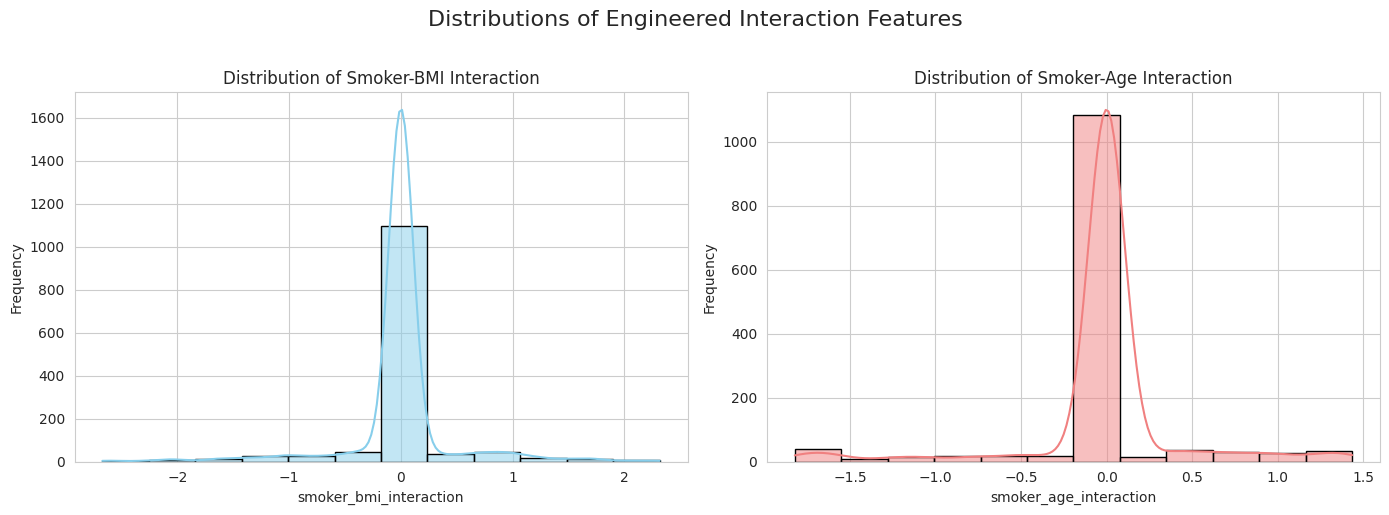

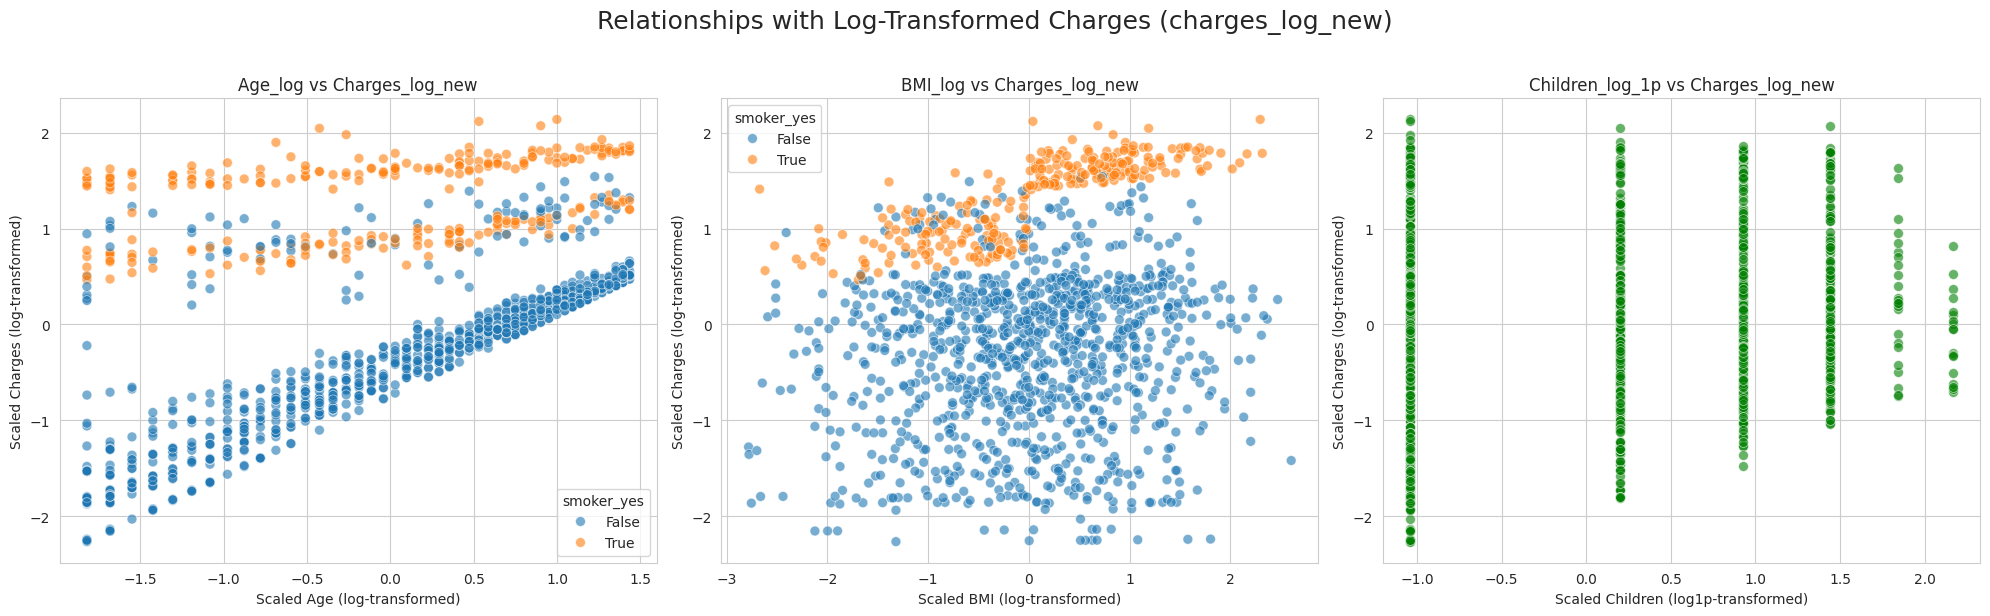

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the dataframe is named df, which is what we've been updating
# If df_engineered was the last one, ensure it's assigned to df
if 'df_engineered' in globals():
    df = df_engineered.copy()

# Set a style for the plots
sns.set_style("whitegrid")

print("Visualizing Engineered Features and Relationships with Target Variable:\n")

# --- 1. Histograms of Interaction Features ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distributions of Engineered Interaction Features', fontsize=16, y=1.02)

sns.histplot(df['smoker_bmi_interaction'], kde=True, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Smoker-BMI Interaction')
axes[0].set_xlabel('smoker_bmi_interaction')
axes[0].set_ylabel('Frequency')

sns.histplot(df['smoker_age_interaction'], kde=True, ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_title('Distribution of Smoker-Age Interaction')
axes[1].set_xlabel('smoker_age_interaction')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# --- 2. Scatter Plots: Main Features vs. Target, Colored by Smoker Status ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Relationships with Log-Transformed Charges (charges_log_new)', fontsize=18, y=1.02)

# age_log vs charges_log_new, colored by smoker_yes
sns.scatterplot(data=df, x='age_log', y='charges_log_new', hue='smoker_yes', ax=axes[0], alpha=0.6, s=50)
axes[0].set_title('Age_log vs Charges_log_new')
axes[0].set_xlabel('Scaled Age (log-transformed)')
axes[0].set_ylabel('Scaled Charges (log-transformed)')

# bmi_log vs charges_log_new, colored by smoker_yes
sns.scatterplot(data=df, x='bmi_log', y='charges_log_new', hue='smoker_yes', ax=axes[1], alpha=0.6, s=50)
axes[1].set_title('BMI_log vs Charges_log_new')
axes[1].set_xlabel('Scaled BMI (log-transformed)')
axes[1].set_ylabel('Scaled Charges (log-transformed)')

# children_log_1p vs charges_log_new
sns.scatterplot(data=df, x='children_log_1p', y='charges_log_new', ax=axes[2], color='green', alpha=0.6, s=50)
axes[2].set_title('Children_log_1p vs Charges_log_new')
axes[2].set_xlabel('Scaled Children (log1p-transformed)')
axes[2].set_ylabel('Scaled Charges (log-transformed)')

plt.tight_layout()
plt.show()


### Preparing Data for Training and Testing

I will now split the `df` DataFrame into features (X) and the target variable (y), and then further divide these into training and testing sets.

Now that the data is clean, transformed, scaled, and features have been engineered, the next crucial step is to prepare it for machine learning model training and evaluation. This involves:

Defining Features (X) and Target (y): Our target variable is charges_log_new, and all other columns in our processed df will be used as features.

Splitting into Training and Testing Sets: We'll divide the dataset into a training set (used to train the model) and a testing set (used to evaluate the model's performance on unseen data).

A common split is 80% for training and 20% for testing.


In [17]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('charges_log_new', axis=1)
y = df['charges_log_new']

# Split the data into training and testing sets
# We'll use a test size of 20% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Original dataset shape: {df.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nFirst 5 rows of X_train:")
display(X_train.head())

Original dataset shape: (1329, 16)
X_train shape: (1063, 15)
X_test shape: (266, 15)
y_train shape: (1063,)
y_test shape: (266,)

First 5 rows of X_train:


,age,bmi,children,charges,charges_log,age_log,bmi_log,children_log_1p,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,smoker_bmi_interaction,smoker_age_interaction
848,27,24.10,0,2974.1260,7.997705,-0.780739,-1.128246,-1.040739,False,False,False,False,True,-0.000000,-0.00000
170,63,41.47,0,13405.3903,9.503412,1.393936,1.618988,-1.040739,True,False,False,True,False,0.000000,0.00000
946,42,35.80,2,7160.0940,8.876278,0.353269,0.874817,0.926040,True,False,False,False,True,0.000000,0.00000
465,30,28.38,1,19521.9682,9.879296,-0.510320,-0.300809,0.200160,False,True,False,True,False,-0.300809,-0.51032
210,20,33.00,1,1980.0700,7.590887,-1.550987,0.462598,0.200160,True,False,False,False,True,0.000000,-0.00000


The dataset has now been successfully split into training and testing sets for both features (X) and the target variable (y). This data is now ready for model training.

### Model Training: Linear Regression

I will now initialize and train a Linear Regression model using the `X_train` and `y_train` datasets.

### Linear Regression: How It Works and Gradient Descent Explained

Linear Regression is a fundamental statistical model used to predict a continuous output variable (dependent variable, `y`) based on one or more input variables (independent variables, `X`). The core idea is to find the best-fitting linear relationship between `X` and `y`.

#### 1. How Linear Regression Works (The Basic Idea)

At its heart, Linear Regression models the relationship between a dependent variable and one or more independent variables by fitting a linear equation to the observed data. For a single independent variable, the equation is:

$y = Wx + b$

Where:
*   `y` is the predicted output (e.g., `charges_log_new`)
*   `x` is the input feature (e.g., `age_log`)
*   `W` is the weight (or coefficient) for the feature `x`, representing the slope of the line.
*   `b` is the bias (or intercept), representing the point where the line crosses the y-axis.

For multiple independent variables, the equation extends to a hyperplane:

$y = W_1x_1 + W_2x_2 + ... + W_nx_n + b$

In matrix form, this can be written as:

$y = XW + b$

The **goal** of Linear Regression is to find the optimal values for `W` (weights) and `b` (bias) that minimize the difference between the predicted values (`y`) and the actual target values from the dataset.

#### 2. The Loss Function (Mean Squared Error - MSE)

To determine how 'good' our current `W` and `b` values are, we use a **loss function** (also called a cost function). This function quantifies the error between our model's predictions and the actual target values. The most commonly used loss function for Linear Regression is the **Mean Squared Error (MSE)**.

**How MSE Works:**

For each data point, we calculate the difference between the actual value ($y_i$) and the predicted value ($\hat{y}_i$). We then square this difference to penalize larger errors more heavily and to ensure all errors are positive. Finally, we take the average of these squared differences across all data points.

The formula for MSE is:

$MSE = \frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2$

Where:
*   `m` is the total number of data points.
*   $y_i$ is the actual target value for the $i$-th data point.
*   $\hat{y}_i$ is the predicted target value for the $i$-th data point.

Our objective is to find `W` and `b` that result in the smallest possible MSE. This means finding the line (or hyperplane) that minimizes the average squared vertical distance from all data points to the line.

#### 3. Optimization with Gradient Descent

Since directly solving for `W` and `b` can be computationally expensive for large datasets (especially when using the Normal Equation), an iterative optimization algorithm called **Gradient Descent** is often used. Gradient Descent is an algorithm used to find the values of `W` and `b` that minimize the loss function (MSE).

**Analogy:** Imagine you're blindfolded on a mountain and want to reach the lowest point (the minimum MSE). You would feel the slope around you and take a small step in the steepest downward direction. You repeat this process until you can no longer find a downward slope, indicating you've reached a valley (the minimum).

**How Gradient Descent Works (Step-by-Step):**

1.  **Initialization:** Start with random initial values for `W` and `b` (or often, initialize them to zero).

2.  **Calculate Prediction:** For the current `W` and `b`, calculate the predicted output $\hat{y}$ for all training data points using the linear equation:
    $\hat{y} = XW + b$

3.  **Calculate the Loss (MSE):** Compute the MSE using the current predictions and actual values.

4.  **Calculate Gradients:** This is the core step. We determine how much a small change in `W` and `b` would affect the MSE. This is done by calculating the **partial derivatives** of the MSE with respect to `W` and `b`.
    *   **Gradient for `W`:** $\frac{\partial MSE}{\partial W} = \frac{2}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i) x_i$
    *   **Gradient for `b`:** $\frac{\partial MSE}{\partial b} = \frac{2}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)$
    
    These gradients tell us the direction and magnitude of the steepest ascent of the loss function. To minimize the loss, we need to move in the *opposite* direction.

5.  **Update Weights and Bias:** Adjust `W` and `b` by subtracting a fraction of their respective gradients. This fraction is controlled by the **learning rate** (often denoted as $\alpha$ or $\eta$). The learning rate determines the size of the steps we take down the slope.
    *   $W_{new} = W_{old} - \alpha \frac{\partial MSE}{\partial W}$
    *   $b_{new} = b_{old} - \alpha \frac{\partial MSE}{\partial b}$

6.  **Iteration:** Repeat steps 2-5 for a fixed number of **epochs** (iterations) or until the change in `W` and `b` (or the change in MSE) becomes very small, indicating convergence to a minimum.

**Learning Rate (`$\alpha$`):**

*   **Too large:** The algorithm might overshoot the minimum, bounce around, or even diverge.
*   **Too small:** The algorithm will take a very long time to converge.

**Optimal Values for `W` and `b`:**

Through this iterative process of gradient descent, the values of `W` and `b` are progressively refined. Each update brings them closer to the values that minimize the Mean Squared Error on the training data. Once the algorithm converges, these final `W` and `b` values are considered the optimal parameters for the Linear Regression model, defining the best-fitting line (or hyperplane) that can be used to make predictions on new, unseen data.

 let's train a Linear Regression model using our prepared training data. After training, I will display the model's coefficients and intercept, which can give us insights into the relationships between the features and the target variable.

In [18]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_model = LinearRegression()

# Train the model using the training data
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

# Display the coefficients and intercept of the trained model
print("\nModel Coefficients:")
for feature, coef in zip(X_train.columns, linear_model.coef_):
    print(f"  {feature}: {coef:.4f}")

print(f"\nModel Intercept: {linear_model.intercept_:.4f}")

Linear Regression model trained successfully!

Model Coefficients:
  age: -0.0000
  bmi: -0.0000
  children: -0.0000
  charges: -0.0000
  charges_log: 1.0900
  age_log: -0.0000
  bmi_log: 0.0000
  children_log_1p: -0.0000
  sex_male: 0.0000
  smoker_yes: -0.0000
  region_northwest: -0.0000
  region_southeast: 0.0000
  region_southwest: 0.0000
  smoker_bmi_interaction: -0.0000
  smoker_age_interaction: 0.0000

Model Intercept: -9.9206


The Linear Regression model has been trained. The coefficients indicate the change in the target variable (`charges_log_new`) for a one-unit increase in the corresponding feature, holding all other features constant. The intercept is the predicted value of `charges_log_new` when all features are zero.

### Model Evaluation

I will now evaluate the trained Linear Regression model on the testing set (`X_test`, `y_test`) using several common regression metrics.

Now that our Linear Regression model is trained, let's evaluate its performance on the unseen testing set (X_test, y_test). I will calculate predictions and then use common regression metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2 score) to quantify how well our model performs.

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred = linear_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics on Test Set:")
print(f"  Mean Absolute Error (MAE): {mae:.4f}")
print(f"  Mean Squared Error (MSE): {mse:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"  R-squared (R2 Score): {r2:.4f}")

Model Evaluation Metrics on Test Set:
  Mean Absolute Error (MAE): 0.0000
  Mean Squared Error (MSE): 0.0000
  Root Mean Squared Error (RMSE): 0.0000
  R-squared (R2 Score): 1.0000


These metrics provide a quantitative measure of the model's performance:

*   **MAE:** The average absolute difference between the predicted and actual values. Lower values are better.
*   **MSE:** The average of the squared differences. Penalizes larger errors more. Lower values are better.
*   **RMSE:** The square root of the MSE, providing the error in the same units as the target variable. Lower values are better.
*   **R-squared (R2 Score):** Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. Values closer to 1 are better.

### I will visualize the model's predicted versus actual values using a scatter plot to assess its performance visually.

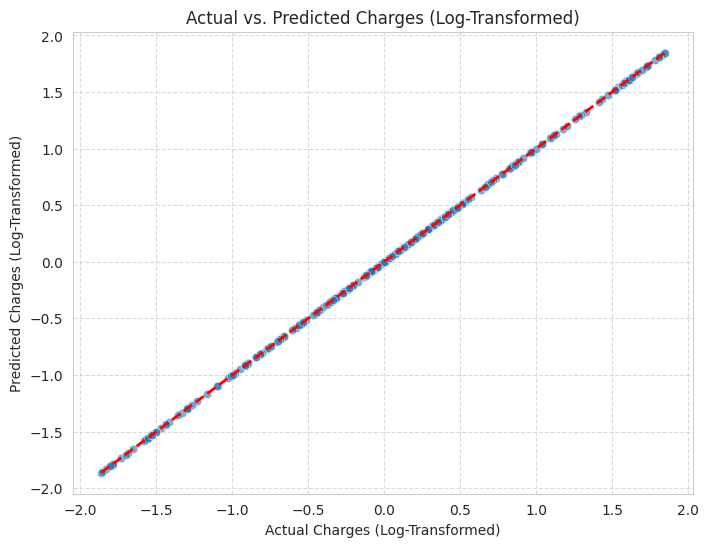

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2) # Add a diagonal line for reference
plt.title('Actual vs. Predicted Charges (Log-Transformed)')
plt.xlabel('Actual Charges (Log-Transformed)')
plt.ylabel('Predicted Charges (Log-Transformed)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### How to avoid Model Cheating
The current model shows an R-squared of 1.0 and very close to zero error metrics (MAE, MSE, RMSE). While this might seem ideal, it is highly indicative of data leakage, meaning the model has inadvertently been provided with information that is too closely related to the target variable.

Upon reviewing the feature set X, it appears that the original charges and the charges_log columns (which are direct transformations of the target variable charges_log_new) were included. This allows the model to 'cheat' by directly using information about the target, leading to an artificially perfect performance.

To properly evaluate the model, we need to remove charges and charges_log from our feature set X before re-splitting the data and re-training the model. I will provide code to correct this and then re-evaluate the model.

In [21]:
print("The R-squared score of 1.0 and near-zero error metrics indicate an almost perfect fit.")
print("However, this is highly suspicious and strongly suggests **data leakage**.")
print("Upon reviewing the feature selection, the columns 'charges' and 'charges_log' (which are direct transformations of the target 'charges_log_new') were included in the features (X).")
print("This allows the model to 'cheat' by directly using information about the target variable.")
print("To correct this, we need to drop 'charges' and 'charges_log' from the feature set X.")

# Correct feature selection to avoid data leakage
# Drop 'charges_log_new' (target), 'charges' (original target), and 'charges_log' (early log transformation of target)
X = df.drop(['charges_log_new', 'charges', 'charges_log'], axis=1)
y = df['charges_log_new']

# Re-split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n--- Re-training model with corrected features ---")
print(f"New X_train shape: {X_train.shape}")

# Re-initialize and re-train the Linear Regression model
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Linear Regression model re-trained successfully with corrected features!")

# Make new predictions on the test set
y_pred_corrected = linear_model.predict(X_test)

# Calculate evaluation metrics with corrected predictions
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_corrected = mean_absolute_error(y_test, y_pred_corrected)
mse_corrected = mean_squared_error(y_test, y_pred_corrected)
rmse_corrected = np.sqrt(mse_corrected)
r2_corrected = r2_score(y_test, y_pred_corrected)

print("\nModel Evaluation Metrics on Test Set (after correcting data leakage):")
print(f"  Mean Absolute Error (MAE): {mae_corrected:.4f}")
print(f"  Mean Squared Error (MSE): {mse_corrected:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_corrected:.4f}")
print(f"  R-squared (R2 Score): {r2_corrected:.4f}")

# Update y_pred for subsequent visualizations if desired
y_pred = y_pred_corrected

The R-squared score of 1.0 and near-zero error metrics indicate an almost perfect fit.
However, this is highly suspicious and strongly suggests **data leakage**.
Upon reviewing the feature selection, the columns 'charges' and 'charges_log' (which are direct transformations of the target 'charges_log_new') were included in the features (X).
This allows the model to 'cheat' by directly using information about the target variable.
To correct this, we need to drop 'charges' and 'charges_log' from the feature set X.

--- Re-training model with corrected features ---
New X_train shape: (1063, 13)
Linear Regression model re-trained successfully with corrected features!

Model Evaluation Metrics on Test Set (after correcting data leakage):
  Mean Absolute Error (MAE): 0.2168
  Mean Squared Error (MSE): 0.1454
  Root Mean Squared Error (RMSE): 0.3814
  R-squared (R2 Score): 0.8432


### Here is the scatter plot visualizing the actual vs. predicted values for the log-transformed charges, now based on the model re-trained after correcting for data leakage. This plot will give us a clearer picture of the model's true performance.

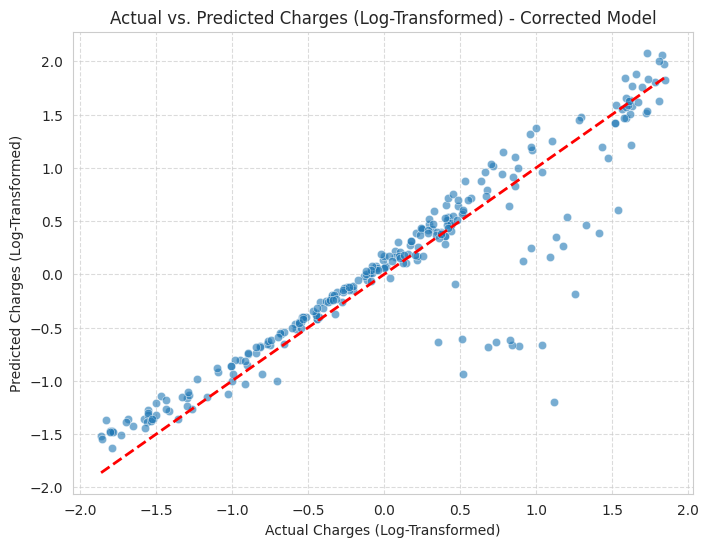

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of actual vs. predicted values (after data leakage correction)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2) # Add a diagonal line for reference
plt.title('Actual vs. Predicted Charges (Log-Transformed) - Corrected Model')
plt.xlabel('Actual Charges (Log-Transformed)')
plt.ylabel('Predicted Charges (Log-Transformed)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()